# Week 6 — Transformer Error Analysis

This notebook is **post-training inference only**. It does not retrain any model.

It loads the five saved DistilBERT checkpoints, recreates the corresponding MELD test examples, generates standardized predictions, and saves:

- `predictions.csv`
- `metrics.json`
- `confusion_matrix.png`
- `classification_report.csv`

The five experiments are:

1. transformer baseline
2. context-1
3. context-3
4. context-5
5. context-1 + speaker

**Non-negotiable MELD rule:** context/adjacency must never cross a dialogue boundary or a missing `Utterance_ID` gap.

Run this notebook locally first to validate the project/data pipeline. The actual trained checkpoints can then be loaded from Google Drive in Colab.


In [1]:
from pathlib import Path
import json
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
)

from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("Python / PyTorch / Transformers ready")
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python / PyTorch / Transformers ready
Torch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
# Colab-only setup
# This cell is harmless locally: it simply does nothing outside Colab.

IN_COLAB = False

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    pass

if IN_COLAB:
    drive.mount("/content/drive")
    DRIVE_CHECKPOINT_ROOT = Path("/content/drive/MyDrive/checkpoints")
    print("Colab detected.")
    print("Drive checkpoints:", DRIVE_CHECKPOINT_ROOT)
else:
    print("Local environment detected.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab detected.
Drive checkpoints: /content/drive/MyDrive/checkpoints


In [3]:
# Project paths
# The repository lives in Google Drive when this notebook runs in Colab.
# Locally, use the repository directory / current notebook location.

COLAB_PROJECT_ROOT = Path("/content/drive/MyDrive/emotion-dynamics-nlp")

if COLAB_PROJECT_ROOT.exists():
    PROJECT_ROOT = COLAB_PROJECT_ROOT
else:
    PROJECT_ROOT = Path.cwd()

    # If the notebook is opened from notebooks/, move to the repository root.
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "meld"
RESULTS_DIR = PROJECT_ROOT / "outputs" / "experiments"
LOCAL_CHECKPOINT_DIR = PROJECT_ROOT / "outputs" / "models"

print("Project root:", PROJECT_ROOT)
print("MELD data:", DATA_DIR)
print("Results:", RESULTS_DIR)
print("Local checkpoints:", LOCAL_CHECKPOINT_DIR)

assert (DATA_DIR / "test_sent_emo.csv").exists(), (
    f"MELD test CSV not found at {DATA_DIR}. "
    "Make sure Google Drive is mounted and the project folder is at "
    "/content/drive/MyDrive/emotion-dynamics-nlp."
)


Project root: /content/drive/MyDrive/emotion-dynamics-nlp
MELD data: /content/drive/MyDrive/emotion-dynamics-nlp/data/raw/meld
Results: /content/drive/MyDrive/emotion-dynamics-nlp/outputs/experiments
Local checkpoints: /content/drive/MyDrive/emotion-dynamics-nlp/outputs/models


In [4]:
LABELS = [
    "anger",
    "disgust",
    "fear",
    "joy",
    "neutral",
    "sadness",
    "surprise",
]

LABEL2ID = {label: i for i, label in enumerate(LABELS)}
ID2LABEL = {i: label for label, i in LABEL2ID.items()}

print(LABEL2ID)


{'anger': 0, 'disgust': 1, 'fear': 2, 'joy': 3, 'neutral': 4, 'sadness': 5, 'surprise': 6}


## 1. Load MELD test data

We use the official test split only. No training or validation data is used here.

For the baseline, every test utterance is eligible.

For context experiments, the target subset must match the context construction used during Week 5.


In [5]:
test_df = pd.read_csv(DATA_DIR / "test_sent_emo.csv")

required_columns = [
    "Utterance",
    "Speaker",
    "Emotion",
    "Dialogue_ID",
    "Utterance_ID",
]

missing = [c for c in required_columns if c not in test_df.columns]
assert not missing, f"Missing MELD columns: {missing}"

test_df = test_df.rename(columns={
    "Utterance": "text",
    "Speaker": "speaker",
    "Emotion": "emotion",
    "Dialogue_ID": "dialogue_id",
    "Utterance_ID": "utterance_id",
})

test_df = test_df.sort_values(
    ["dialogue_id", "utterance_id"]
).reset_index(drop=True)

assert test_df["text"].notna().all()
assert test_df["emotion"].isin(LABELS).all()

print("Test utterances:", len(test_df))
print("Dialogues:", test_df["dialogue_id"].nunique())
test_df.head()


Test utterances: 2610
Dialogues: 280


,Sr No.,text,speaker,emotion,Sentiment,dialogue_id,utterance_id,Season,Episode,StartTime,EndTime
0,1,Why do all you’re coffee mugs have numbers on ...,Mark,surprise,positive,0,0,3,19,"00:14:38,127","00:14:40,378"
1,2,Oh. That’s so Monica can keep track. That way ...,Rachel,anger,negative,0,1,3,19,"00:14:40,629","00:14:47,385"
2,3,Y'know what?,Rachel,neutral,neutral,0,2,3,19,"00:14:56,353","00:14:57,520"
3,19,"Come on, Lydia, you can do it.",Joey,neutral,neutral,1,0,1,23,"0:10:44,769","0:10:46,146"
4,20,Push!,Joey,joy,positive,1,1,1,23,"0:10:46,146","0:10:46,833"


## 2. Recreate context examples

The project already has `src.data.context.build_context_examples`.

We use that existing implementation rather than writing a second context-construction algorithm.

If the local function signature differs, the next cell prints it so we can adjust the adapter rather than silently changing the experiment definition.


In [6]:
# Clone/update the project repository in Colab

import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/duckydodo/emotion-dynamics-nlp"
COLAB_REPO = Path("/content/emotion-dynamics-nlp")

if not COLAB_REPO.exists():
    subprocess.run(
        ["git", "clone", REPO_URL, str(COLAB_REPO)],
        check=True,
    )
else:
    subprocess.run(
        ["git", "-C", str(COLAB_REPO), "pull"],
        check=True,
    )

os.chdir(COLAB_REPO)

# Make src importable
import sys
if str(COLAB_REPO) not in sys.path:
    sys.path.insert(0, str(COLAB_REPO))

print("Repository:", COLAB_REPO)
print("Working directory:", Path.cwd())

Repository: /content/emotion-dynamics-nlp
Working directory: /content/emotion-dynamics-nlp


In [7]:
from src.data.context import build_context_examples

print(inspect.signature(build_context_examples))


(df: pandas.core.frame.DataFrame, context_turns: int = 1, include_speaker: bool = False) -> pandas.core.frame.DataFrame


In [8]:
def make_context_examples(df, context_turns, include_speaker=False):
    """Compatibility wrapper around the project's existing context builder."""
    kwargs = {}

    signature = inspect.signature(build_context_examples)
    params = signature.parameters

    # The Week 5 implementation is expected to accept these names.
    candidates = {
        "context_turns": context_turns,
        "include_speaker": include_speaker,
        "speaker_tokens": include_speaker,
    }

    for name, value in candidates.items():
        if name in params:
            kwargs[name] = value

    # Prefer the existing implementation and expose failures clearly.
    result = build_context_examples(df, **kwargs)

    if isinstance(result, pd.DataFrame):
        out = result.copy()
    else:
        out = pd.DataFrame(result)

    print("Context builder returned:", out.shape)
    print("Columns:", list(out.columns))
    return out


### Context sanity check

Run this before loading any model.

We need to verify that the generated context data actually contains the target label and text used by the Week 5 training pipeline.


In [9]:
sample_context = make_context_examples(
    test_df,
    context_turns=1,
    include_speaker=False,
)

display(sample_context.head())


Context builder returned: (2328, 6)
Columns: ['dialogue_id', 'utterance_id', 'speaker', 'text', 'emotion', 'context']


,dialogue_id,utterance_id,speaker,text,emotion,context
0,0,1,Rachel,Oh. That’s so Monica can keep track. That way ...,anger,Why do all you’re coffee mugs have numbers on ...
1,0,2,Rachel,Y'know what?,neutral,Oh. That’s so Monica can keep track. That way ...
2,1,1,Joey,Push!,joy,"Come on, Lydia, you can do it.\nPush!"
3,1,2,Joey,"Push 'em out, push 'em out, harder, harder.",joy,"Push!\nPush 'em out, push 'em out, harder, har..."
4,1,3,Joey,"Push 'em out, push 'em out, way out!",joy,"Push 'em out, push 'em out, harder, harder.\nP..."


In [10]:
# Inspect likely text/label columns so we do not silently guess.
print("Columns:", list(sample_context.columns))


Columns: ['dialogue_id', 'utterance_id', 'speaker', 'text', 'emotion', 'context']


## 3. Normalize context examples

This adapter accepts the project's existing context DataFrame and normalizes common field names.

If an expected field is missing, this cell intentionally stops rather than guessing.


In [11]:
def normalize_examples(df, use_context=False):
    df = df.copy()

    label_candidates = [
        "emotion",
        "label",
        "target",
        "target_label",
    ]

    if use_context:
        if "context" not in df.columns:
            raise ValueError(
                "Contextual inference requested, but 'context' "
                f"column is missing. Available columns: {list(df.columns)}"
            )

        text_col = "context"

    else:
        text_candidates = [
            "text",
            "input_text",
            "context_text",
            "model_input",
        ]

        text_col = next(
            (c for c in text_candidates if c in df.columns),
            None,
        )

    label_col = next(
        (c for c in label_candidates if c in df.columns),
        None,
    )

    if text_col is None or label_col is None:
        raise ValueError(
            "Could not identify text/label columns. "
            f"Available columns: {list(df.columns)}"
        )

    out = df.copy()

    # This is the actual text fed into the model.
    out["model_text"] = out[text_col].astype(str)

    if pd.api.types.is_numeric_dtype(out[label_col]):
        out["label_id"] = out[label_col].astype(int)
        out["true_emotion"] = out["label_id"].map(ID2LABEL)
    else:
        out["true_emotion"] = out[label_col].astype(str)
        out["label_id"] = out["true_emotion"].map(LABEL2ID)

    if out["label_id"].isna().any():
        bad = out.loc[
            out["label_id"].isna(),
            "true_emotion"
        ].unique()

        raise ValueError(
            f"Unknown emotion labels: {bad}"
        )

    return out.reset_index(drop=True)

In [18]:
# Prepare the utterance-only baseline examples

baseline_examples = normalize_examples(
    test_df,
    use_context=False,
)

print("Baseline examples:", baseline_examples.shape)
print("Columns:", list(baseline_examples.columns))
print("\nFirst model input:")
print(baseline_examples.iloc[0]["model_text"])
print("\nTarget emotion:")
print(baseline_examples.iloc[0]["true_emotion"])

Baseline examples: (2610, 14)
Columns: ['Sr No.', 'text', 'speaker', 'emotion', 'Sentiment', 'dialogue_id', 'utterance_id', 'Season', 'Episode', 'StartTime', 'EndTime', 'model_text', 'true_emotion', 'label_id']

First model input:
Why do all you’re coffee mugs have numbers on the bottom?

Target emotion:
surprise


## 4. Checkpoint configuration

### Local validation

If a trained checkpoint has already been copied into `outputs/models/`, point `LOCAL_CHECKPOINT_DIR` at it.

### Colab

For the actual inference run, set `DRIVE_CHECKPOINT_ROOT` to the mounted Google Drive `checkpoints/` directory.

The Drive checkpoint structure shown during Week 5 is:

```text
checkpoints/
├── transformer_baseline/
├── transformer_context_1/
├── transformer_context_3/
├── transformer_context_5/
└── transformer_context_1_speaker/
```

Each `best/` directory contains `config.json`, `model.safetensors`, tokenizer files, and training configuration.


In [12]:
# Transformer checkpoint locations

# In Colab, checkpoints are stored inside the project folder on Google Drive.
DRIVE_CHECKPOINT_ROOT = PROJECT_ROOT / "checkpoints"

assert DRIVE_CHECKPOINT_ROOT.exists(), (
    f"Checkpoint directory not found: {DRIVE_CHECKPOINT_ROOT}"
)

EXPERIMENTS = {
    "transformer_baseline": {
        "context_turns": 0,
        "include_speaker": False,
    },
    "transformer_context_1": {
        "context_turns": 1,
        "include_speaker": False,
    },
    "transformer_context_3": {
        "context_turns": 3,
        "include_speaker": False,
    },
    "transformer_context_5": {
        "context_turns": 5,
        "include_speaker": False,
    },
    "transformer_context_1_speaker": {
        "context_turns": 1,
        "include_speaker": True,
    },
}


def find_checkpoint(experiment_name):
    root = DRIVE_CHECKPOINT_ROOT / experiment_name / "best"

    assert root.exists(), (
        f"Checkpoint directory not found: {root}"
    )

    assert (root / "config.json").exists(), (
        f"Missing config.json: {root}"
    )

    assert (root / "model.safetensors").exists(), (
        f"Missing model.safetensors: {root}"
    )

    return root

In [13]:
# Verify which checkpoints are available.
for name in EXPERIMENTS:
    print(f"{name}: {find_checkpoint(name)}")


transformer_baseline: /content/drive/MyDrive/emotion-dynamics-nlp/checkpoints/transformer_baseline/best
transformer_context_1: /content/drive/MyDrive/emotion-dynamics-nlp/checkpoints/transformer_context_1/best
transformer_context_3: /content/drive/MyDrive/emotion-dynamics-nlp/checkpoints/transformer_context_3/best
transformer_context_5: /content/drive/MyDrive/emotion-dynamics-nlp/checkpoints/transformer_context_5/best
transformer_context_1_speaker: /content/drive/MyDrive/emotion-dynamics-nlp/checkpoints/transformer_context_1_speaker/best


## 5. Inference utilities

Inference preserves the model's probability distribution. We need probabilities later for trajectory and turning-point analysis, not only hard labels.


In [14]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_checkpoint(checkpoint_path):
    checkpoint_path = Path(checkpoint_path)

    tokenizer = AutoTokenizer.from_pretrained(checkpoint_path)
    model = AutoModelForSequenceClassification.from_pretrained(checkpoint_path)

    model.to(DEVICE)
    model.eval()

    return tokenizer, model


@torch.no_grad()
def predict_examples(examples, checkpoint_path, batch_size=16, max_length=128):
    tokenizer, model = load_checkpoint(checkpoint_path)

    texts = examples["model_text"].tolist()
    all_probs = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )

        encoded = {k: v.to(DEVICE) for k, v in encoded.items()}

        logits = model(**encoded).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()

        all_probs.append(probs)

    probabilities = np.vstack(all_probs)
    predictions = probabilities.argmax(axis=1)

    return predictions, probabilities


In [15]:
def evaluate_predictions(examples, predictions):
    y_true = examples["label_id"].to_numpy()
    y_pred = np.asarray(predictions)

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(LABELS))),
        zero_division=0,
    )

    report = pd.DataFrame({
        "emotion": LABELS,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
    })

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(len(LABELS))),
    )

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "classification_report": report,
        "confusion_matrix": cm,
    }


def save_experiment_outputs(name, examples, predictions, probabilities, metrics):
    out_dir = RESULTS_DIR / name
    out_dir.mkdir(parents=True, exist_ok=True)

    pred_df = examples.copy()
    pred_df["predicted_id"] = predictions
    pred_df["predicted_emotion"] = [ID2LABEL[i] for i in predictions]
    pred_df["correct"] = pred_df["label_id"].to_numpy() == predictions

    for i, label in ID2LABEL.items():
        pred_df[f"prob_{label}"] = probabilities[:, i]

    pred_df.to_csv(out_dir / "predictions.csv", index=False)

    metrics_json = {
        "experiment": name,
        "test_examples": int(len(examples)),
        "test_accuracy": float(metrics["accuracy"]),
        "test_macro_f1": float(metrics["macro_f1"]),
        "test_weighted_f1": float(metrics["weighted_f1"]),
    }

    with open(out_dir / "metrics.json", "w") as f:
        json.dump(metrics_json, f, indent=2)

    metrics["classification_report"].to_csv(
        out_dir / "classification_report.csv",
        index=False,
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(metrics["confusion_matrix"])
    ax.set_xticks(range(len(LABELS)))
    ax.set_yticks(range(len(LABELS)))
    ax.set_xticklabels(LABELS, rotation=45, ha="right")
    ax.set_yticklabels(LABELS)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix — {name}")

    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            ax.text(j, i, str(metrics["confusion_matrix"][i, j]),
                    ha="center", va="center")

    fig.colorbar(im)
    plt.tight_layout()
    fig.savefig(out_dir / "confusion_matrix.png", dpi=300)
    plt.show()

    return pred_df


## 6. Run one experiment first

Do **not** immediately run all five.

Start with the baseline. Once the baseline loads and produces predictions correctly, run the four contextual experiments.


In [16]:
context_test = normalize_examples(
    make_context_examples(
        test_df,
        context_turns=1,
        include_speaker=False,
    ),
    use_context=True,
)

print("Model input:")
print(context_test.iloc[0]["model_text"])

print("\nTarget utterance:")
print(context_test.iloc[0]["text"])

assert context_test.iloc[0]["model_text"] != context_test.iloc[0]["text"], (
    "Contextual model input is identical to target text. "
    "Context is NOT being passed to the model."
)

assert context_test.iloc[0]["text"] in context_test.iloc[0]["model_text"], (
    "Target utterance is missing from contextual model input."
)

print("\nContext input validation passed.")

Context builder returned: (2328, 6)
Columns: ['dialogue_id', 'utterance_id', 'speaker', 'text', 'emotion', 'context']
Model input:
Why do all you’re coffee mugs have numbers on the bottom?
Oh. That’s so Monica can keep track. That way if one on them is missing, she can be like, ‘Where’s number 27?!’

Target utterance:
Oh. That’s so Monica can keep track. That way if one on them is missing, she can be like, ‘Where’s number 27?!’

Context input validation passed.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Accuracy:    0.6031
Macro F1:    0.4400
Weighted F1: 0.6054


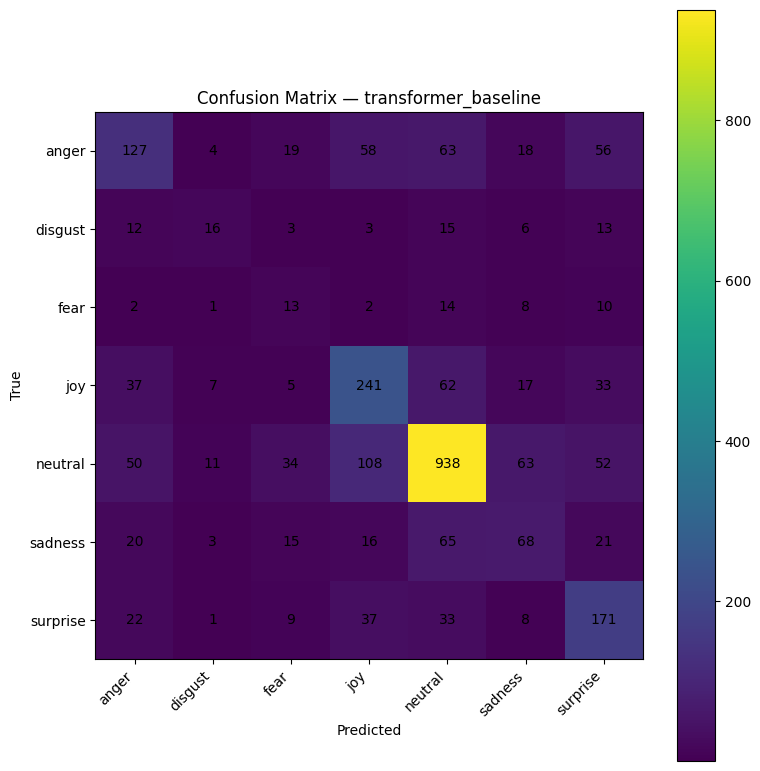

In [19]:
# Baseline first
baseline_checkpoint = find_checkpoint("transformer_baseline")

if baseline_checkpoint is None:
    print(
        "No baseline checkpoint found locally. "
        "This is expected until the checkpoint is available in outputs/models/ "
        "or Google Drive is mounted in Colab."
    )
else:
    predictions, probabilities = predict_examples(
        baseline_examples,
        baseline_checkpoint,
        batch_size=16,
        max_length=128,
    )

    metrics = evaluate_predictions(baseline_examples, predictions)

    print(f"Accuracy:    {metrics['accuracy']:.4f}")
    print(f"Macro F1:    {metrics['macro_f1']:.4f}")
    print(f"Weighted F1: {metrics['weighted_f1']:.4f}")

    baseline_predictions = save_experiment_outputs(
        "transformer_baseline",
        baseline_examples,
        predictions,
        probabilities,
        metrics,
    )

    baseline_predictions.head()


## 7. Run all available experiments

For context models, the examples are recreated using the project's existing context builder.

The notebook intentionally reports the number of test examples for each experiment because context windows naturally have smaller eligible test sets.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

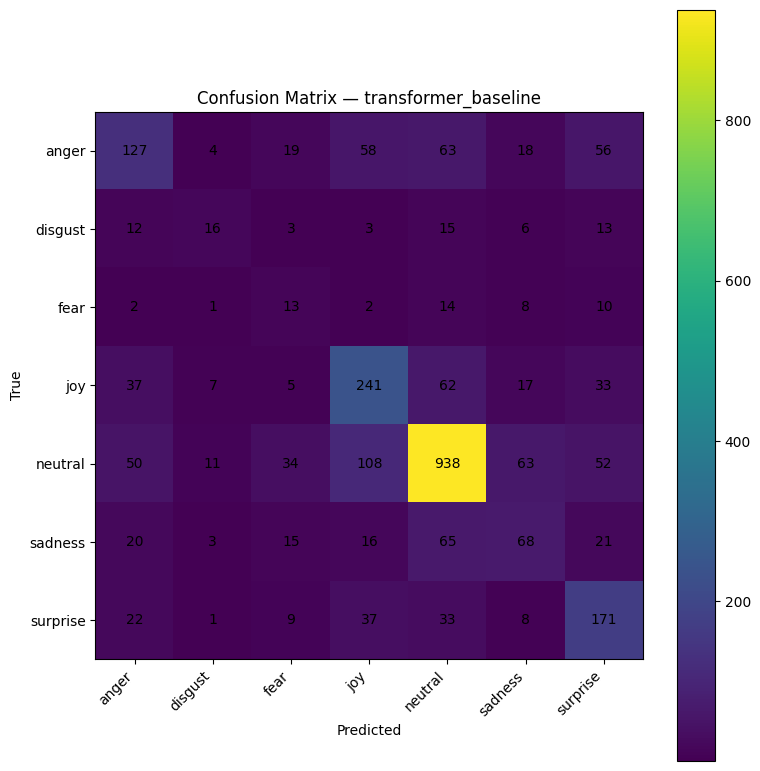

Context builder returned: (2328, 6)
Columns: ['dialogue_id', 'utterance_id', 'speaker', 'text', 'emotion', 'context']


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

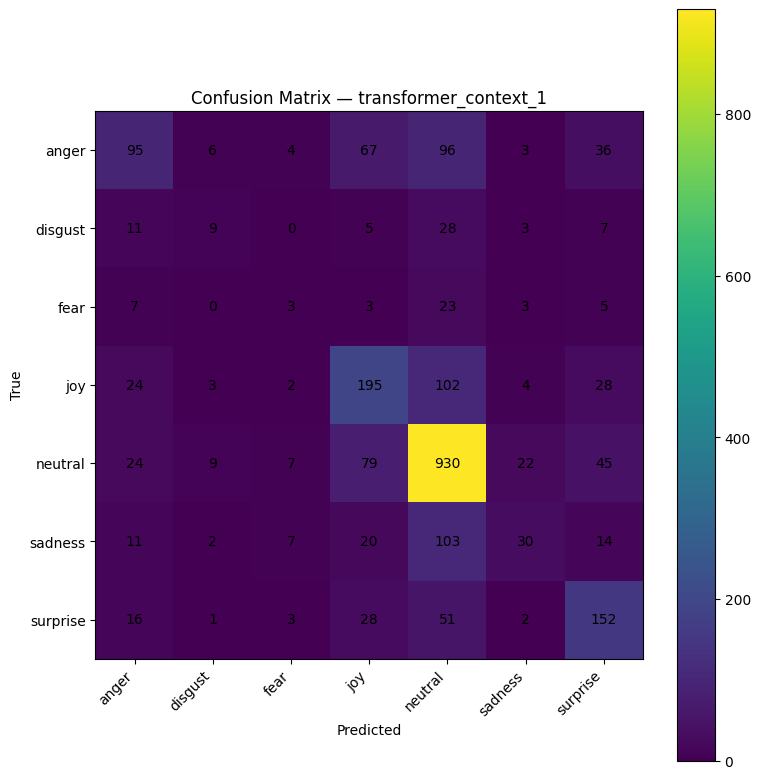

Context builder returned: (1807, 6)
Columns: ['dialogue_id', 'utterance_id', 'speaker', 'text', 'emotion', 'context']


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

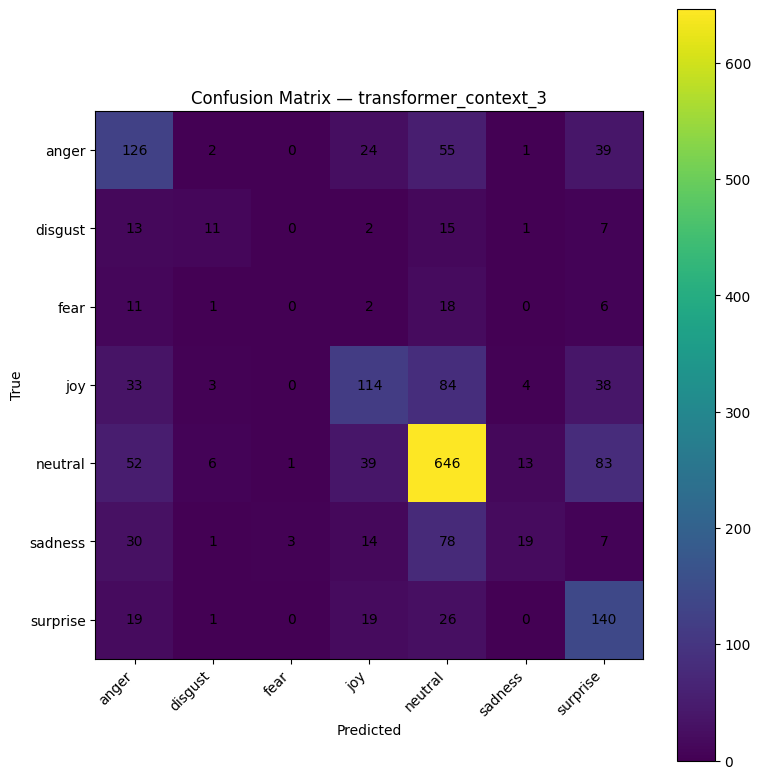

Context builder returned: (1354, 6)
Columns: ['dialogue_id', 'utterance_id', 'speaker', 'text', 'emotion', 'context']


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

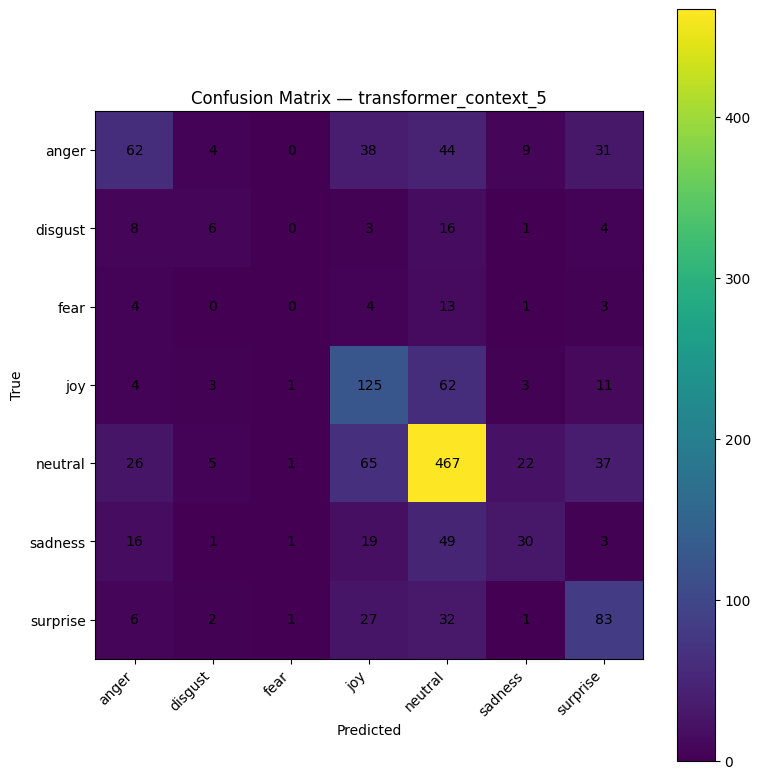

Context builder returned: (2328, 6)
Columns: ['dialogue_id', 'utterance_id', 'speaker', 'text', 'emotion', 'context']


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

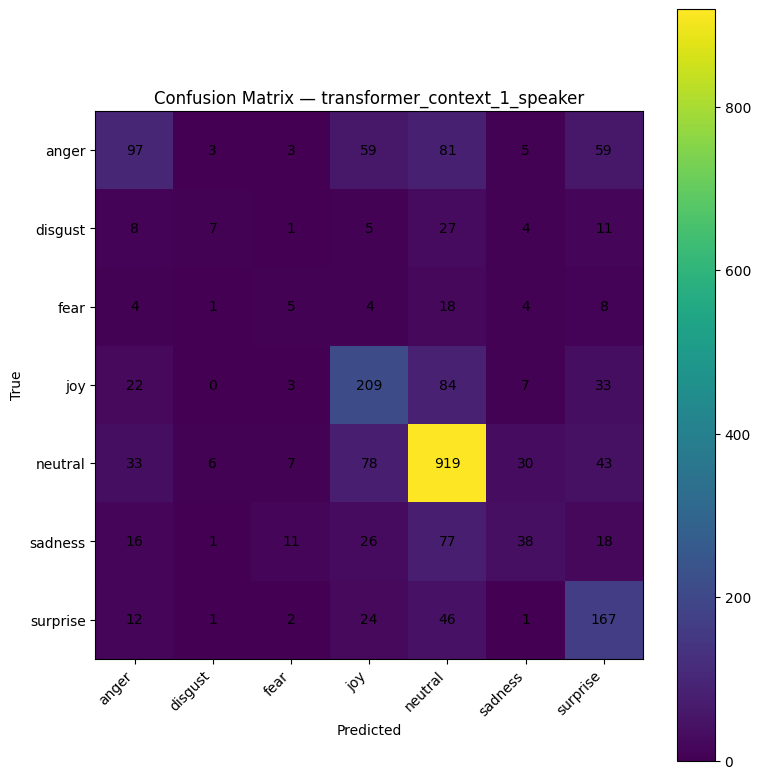

,experiment,test_examples,accuracy,macro_f1,weighted_f1
0,transformer_baseline,2610,0.603065,0.440029,0.605354
1,transformer_context_1,2328,0.607388,0.391191,0.581155
2,transformer_context_3,1807,0.584394,0.386253,0.562193
3,transformer_context_5,1354,0.570901,0.379798,0.554219
4,transformer_context_1_speaker,2328,0.619416,0.407809,0.598144


In [20]:
all_results = []
prediction_frames = {}

for name, config in EXPERIMENTS.items():
    checkpoint = find_checkpoint(name)

    if checkpoint is None:
        print(f"SKIP {name}: checkpoint not available")
        continue

    if config["context_turns"] == 0:
        examples = baseline_examples
    else:
        raw_examples = make_context_examples(
            test_df,
            context_turns=config["context_turns"],
            include_speaker=config["include_speaker"],
        )
        examples = normalize_examples(
            raw_examples,
            use_context=True,
        )

    predictions, probabilities = predict_examples(
        examples,
        checkpoint,
        batch_size=16,
        max_length=128,
    )

    metrics = evaluate_predictions(examples, predictions)

    pred_df = save_experiment_outputs(
        name,
        examples,
        predictions,
        probabilities,
        metrics,
    )

    prediction_frames[name] = pred_df

    all_results.append({
        "experiment": name,
        "test_examples": len(examples),
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "weighted_f1": metrics["weighted_f1"],
    })

results_df = pd.DataFrame(all_results)
results_df


## 8. Error-analysis views

The saved `predictions.csv` files now contain the true label, predicted label, text/context, and class probabilities.

This lets us systematically inspect:

- false positives/false negatives by emotion,
- neutral absorption of minority emotions,
- examples corrected by speaker information,
- examples harmed by added context,
- high-confidence mistakes,
- low-confidence/ambiguous predictions.


In [21]:
# Example: highest-confidence errors for the first available model
if prediction_frames:
    first_name = next(iter(prediction_frames))
    pred_df = prediction_frames[first_name]

    prob_cols = [f"prob_{label}" for label in LABELS]
    pred_df["prediction_confidence"] = pred_df[prob_cols].max(axis=1)

    high_conf_errors = (
        pred_df[~pred_df["correct"]]
        .sort_values("prediction_confidence", ascending=False)
        .head(20)
    )

    display(
        high_conf_errors[
            [c for c in [
                "dialogue_id",
                "utterance_id",
                "speaker",
                "text",
                "true_emotion",
                "predicted_emotion",
                "prediction_confidence",
            ] if c in high_conf_errors.columns]
        ]
    )


,dialogue_id,utterance_id,speaker,text,true_emotion,predicted_emotion,prediction_confidence
1884,199,4,Rachel,"Well uh, his answering machine was",sadness,neutral,0.990116
1389,150,0,Janice,"Honey, honey, people are looking.",sadness,neutral,0.986307
1679,175,16,Rachel,"Y’know what Tag, if we went down to the office...",anger,neutral,0.983618
2240,240,15,Joey,"Oh uh, one of the writers.",sadness,neutral,0.981564
900,100,15,Phoebe,Where is Leslie?,fear,neutral,0.975588
2318,249,0,Mr. Kaplan,Eh.,joy,neutral,0.975066
904,100,19,Phoebe,"Leslie, now would be a",sadness,neutral,0.972598
903,100,18,Phoebe,Where are you Leslie?,fear,neutral,0.972325
56,7,6,Monica,What’s fish hooking?,surprise,neutral,0.972211
2277,244,6,Chandler,"Well let’s see, there was the guy with the fer...",disgust,neutral,0.972157


In [22]:
# Cross-model comparison on the matched Context-1 target set.
# This is the appropriate comparison for Context-1 vs utterance-only.

if "transformer_context_1" in prediction_frames:
    ctx1 = prediction_frames["transformer_context_1"]

    # Context examples should retain target identifiers from the existing builder.
    id_pairs = [c for c in ["dialogue_id", "utterance_id"] if c in ctx1.columns]

    if len(id_pairs) == 2 and "transformer_baseline" in prediction_frames:
        base = prediction_frames["transformer_baseline"]

        merged = ctx1.merge(
            base[
                id_pairs + [
                    "true_emotion",
                    "predicted_emotion",
                    "correct",
                ]
            ].rename(columns={
                "predicted_emotion": "baseline_predicted_emotion",
                "correct": "baseline_correct",
            }),
            on=id_pairs,
            suffixes=("", "_baseline"),
        )

        merged["context_corrected"] = (
            (~merged["baseline_correct"]) & (merged["correct"])
        )
        merged["context_harmed"] = (
            (merged["baseline_correct"]) & (~merged["correct"])
        )

        print("Baseline wrong → Context-1 correct:",
              int(merged["context_corrected"].sum()))
        print("Baseline correct → Context-1 wrong:",
              int(merged["context_harmed"].sum()))

        display(
            merged[
                merged["context_corrected"] | merged["context_harmed"]
            ][
                id_pairs
                + ["text", "true_emotion",
                   "baseline_predicted_emotion",
                   "predicted_emotion",
                   "baseline_correct", "correct"]
            ].head(30)
        )


Baseline wrong → Context-1 correct: 259
Baseline correct → Context-1 wrong: 229


,dialogue_id,utterance_id,text,true_emotion,baseline_predicted_emotion,predicted_emotion,baseline_correct,correct
0,0,1,Oh. That’s so Monica can keep track. That way ...,anger,anger,neutral,True,False
3,1,2,"Push 'em out, push 'em out, harder, harder.",joy,joy,neutral,True,False
4,1,3,"Push 'em out, push 'em out, way out!",joy,fear,joy,False,True
7,1,6,Push!,joy,anger,joy,False,True
12,2,4,"Okay, y'know what? There is no more left, left!",anger,anger,joy,True,False
20,3,2,Howard's the,neutral,neutral,joy,True,False
26,4,2,It kicked! I think the baby kicked!,surprise,surprise,anger,True,False
30,4,6,"Oh wait, Joey, you can’t go like that! You stink!",disgust,surprise,disgust,False,True
31,4,7,"Look, I know I feel asleep before I could show...",anger,sadness,anger,False,True
32,4,8,"They’re just ten blocks away, if I run, I can ...",neutral,fear,neutral,False,True


## 9. Save the consolidated Week 6 table

This produces a compact result artifact that can be committed to GitHub.


In [23]:
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

if not results_df.empty:
    results_df.to_csv(
        TABLES_DIR / "week6_transformer_comparison.csv",
        index=False,
    )

results_df


,experiment,test_examples,accuracy,macro_f1,weighted_f1
0,transformer_baseline,2610,0.603065,0.440029,0.605354
1,transformer_context_1,2328,0.607388,0.391191,0.581155
2,transformer_context_3,1807,0.584394,0.386253,0.562193
3,transformer_context_5,1354,0.570901,0.379798,0.554219
4,transformer_context_1_speaker,2328,0.619416,0.407809,0.598144
